In [2]:
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
plt.style.use('/Users/amonast/Documents/GitHub/CA1_Engram_Dynamics/figures/paper_style.mplstyle')
palette1 = {'EN': '#FFC40C', 'NN': '#00ABC8', 'EE': '#F37243'}

In [3]:
savepath='/Users/amonast/BOSTON UNIVERSITY Dropbox/Amy Monasterio/Manuscripts/Engram2P/Figures/RevisionFigures/Round2'

# CS + Trace (REST + RUN matched)

In [3]:
df3 = pd.read_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/delta_corr_recall1_cstrace_behmatch_thr_overlap.csv',index_col=0)

## Pointplot - Mean

In [5]:
df3['delta_corr_norm_abs'] = np.abs(df3['delta_corr_norm'])

/var/folders/4k/5kmnnrq94j136038_jy_4twc0000gq/T/ipykernel_49863/92530161.py:30: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


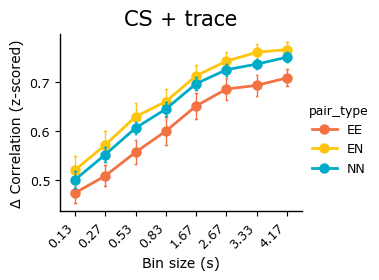

In [ ]:
title = 'CS + trace'
dv='delta_corr_norm_abs'

ani_mean = True
data =  (df3.groupby(['group', 'animal', 'pair_type', 'bin_size'])[[dv]]
            .mean()
            .reset_index())
g = sb.catplot(
        data=data,
        hue='pair_type',
        x='bin_size',
        y=dv,
        kind='point',
        capsize=0.05,
        markersize=6,
        palette=palette1,
        markers='o',
        linewidth=2,
        height=2.5,aspect=1.3,
        dodge=0,
        legend=True,
        errorbar='se',
        err_kws=dict(lw=1))

for ax in g.axes.flatten():
    # ax.axhline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('Bin size (s)')
    ax.set_ylabel("\u0394 Correlation (z-scored)")    
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.savefig('Figure5F_pointplot_deltaR_abs_z.svg',transparent=True)

In [9]:
import statsmodels.formula.api as smf

formula = 'delta_corr_norm_abs ~ pair_type + bin_size'

model_abs = smf.mixedlm(formula, data, groups=data['animal']).fit()

print("=== Abs Val ===")
print(model_abs.summary())


=== Abs Val ===
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_corr_norm_abs
No. Observations: 264     Method:             REML               
No. Groups:       11      Scale:              0.0036             
Min. group size:  24      Log-Likelihood:     340.0776           
Max. group size:  24      Converged:          Yes                
Mean group size:  24.0                                           
------------------------------------------------------------------
                    Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept           0.517     0.016  32.397  0.000   0.486   0.549
pair_type[T.EN]     0.061     0.009   6.754  0.000   0.043   0.079
pair_type[T.NN]     0.042     0.009   4.653  0.000   0.024   0.060
bin_size            0.054     0.003  21.093  0.000   0.049   0.059
Group Var           0.002     0.018                               


/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [10]:
model_abs.pvalues

Intercept          3.069130e-230
pair_type[T.EN]     1.438097e-11
pair_type[T.NN]     3.266699e-06
bin_size            9.260501e-99
Group Var           4.031711e-02
dtype: float64

In [8]:
pairs = {
    'EN vs EE': np.array([[0,  1,  0, 0]]),
    'NN vs EE': np.array([[0,  0,  1, 0]]),
    'EN vs NN': np.array([[0,  1, -1, 0]]),
}

results = {}
for name, contrast in pairs.items():
    test = model_abs.t_test(contrast)
    results[name] = {'coef': test.effect[0], 'p': test.pvalue}

# Apply Bonferroni correction (3 comparisons)
import pandas as pd
df_res = pd.DataFrame(results).T
df_res['p_bonferroni'] = (df_res['p'] * 3).clip(upper=1)
print(df_res)

              coef                       p p_bonferroni
EN vs EE  0.060844  1.4380966201051096e-11          0.0
NN vs EE   0.04192  3.2666987410767374e-06      0.00001
EN vs NN  0.018925      0.0356657605616501     0.106997


NameError: name 'savepath' is not defined

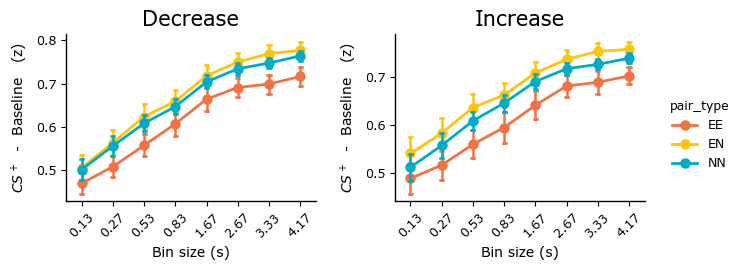

In [ ]:
data=df3.copy()
ani_mean=True
dv='delta_corr_norm_abs'

sign_labels = {1.0: 'Increased', -1.0: 'Decreased'}

plot_data = data.copy()
if ani_mean:
    plot_data = (plot_data
        .groupby(['group', 'animal', 'pair_type', 'bin_size', 'delta_corr_sign'])[[dv]]
        .mean()
        .reset_index())

plot_data['sign_label'] = plot_data['delta_corr_sign'].map(sign_labels)
g = sb.catplot(
    data=plot_data,
    col='sign_label',
    hue='pair_type',
    x='bin_size',
    y=dv,
    kind='point',
    capsize=0.1,
    palette=palette1,
    markers='o',
    sharey=False,
    linestyles='-',
    dodge=0,
    markersize=6,
    linewidth=2,
    errorbar='se',
    err_kws=dict(lw=1.8),
    height=2.8,
    aspect=1.2)

for ax, title in zip(g.axes.flat, ['Decrease','Increase']):
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Bin size (s)')
    ax.set_ylabel('$CS^+$  -  Baseline   (z)')    
g.tight_layout()
plt.savefig(f"_signed_pointplot_cstrace.svg",transparent=True)

#### LME 

In [18]:
import statsmodels.formula.api as smf

formula = 'delta_corr_norm ~ pair_type + bin_size'

inc = plot_data[plot_data['delta_corr_sign'] == 1.0]
dec = plot_data[plot_data['delta_corr_sign'] == -1.0]

model_inc = smf.mixedlm(formula, inc, groups=inc['animal']).fit()
model_dec = smf.mixedlm(formula, dec, groups=dec['animal']).fit()

print("=== Increased ===")
print(model_inc.summary())
print("=== Decreased ===")
print(model_dec.summary())


=== Increased ===
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_corr_norm
No. Observations: 264     Method:             REML           
No. Groups:       11      Scale:              0.0040         
Min. group size:  24      Log-Likelihood:     322.5408       
Max. group size:  24      Converged:          Yes            
Mean group size:  24.0                                       
-------------------------------------------------------------
                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.763    0.025 30.939 0.000  0.715  0.811
pair_type[T.EN]     0.100    0.009 10.583 0.000  0.082  0.119
pair_type[T.NN]     0.069    0.009  7.309 0.000  0.051  0.088
bin_size            0.017    0.003  6.426 0.000  0.012  0.023
Group Var           0.006    0.044                           

=== Decreased ===
            Mixed Linear Model Regression Res

/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/amonast/opt/anaconda3/envs/caiman/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
